# Hypothesis Testing: Applied Case Study (Insurance Charges)

## Problem Statement
Answer four specific business questions with statistical evidence: (a) do smokers' charges differ from non-smokers'? (b) does BMI differ by gender? (c) does smoking proportion differ by gender? (d) does BMI differ across women with 0/1/2 children?

## Dataset
Same insurance charges dataset as the concepts notebook (age, bmi, children, smoker, region, charges, etc.).

## Approach
Full EDA followed by four hypothesis tests: two independent-samples t-tests (`ttest_ind`), a chi-square test of independence (`chi2_contingency`), and a one-way ANOVA (`f_oneway`), each with an explicit null/alternative hypothesis.

## Conclusion
Each test's p-value is compared against alpha=0.05 to accept/reject the null hypothesis -- a template for statistically-backed business decisions rather than eyeballing charts.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
#the module which is dedciated to work on statistics
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder

In [3]:
data = pd.read_csv('insurance_data.csv')

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#Task
#perfrom basic EDA which should include:
#a.shape of data
#b.data type for each attribute
#c.Checking for the presence of missing values
#d. 5 number summary of data
#e. Distrinution of bmi, age, charges colums
#f. Check for presence of outliers in bmi, age, charges column
#g. Measure of skweness of bmi, age, charges column
#h.  Distribution of categorical columns
#i. Pairplot that incluces all the columns of data

In [ ]:
#Answer the follow Question with statistical evidence 
#a. Do charges of people who smoke differ significantly from the people who don't?
#b. Does bmi of males differ signifcantly from that of females?
#c. Is the proportion of smokers significantly different in different gender?
#d. the proportion of of bmi across women with no children,one child and two children,the same? 

In [5]:
#a.shape of data
data.shape

(1338, 7)

In [6]:
#b.data type for each attribute
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
#c. Checking for the presence of missing values
#using isnull we can check NAN is presnt or not
data.isnull().values.any()

False

In [8]:
#d. 5 number summary of data
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\moham\AppData\Local\Temp\ipykernel_15696\3007011738.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

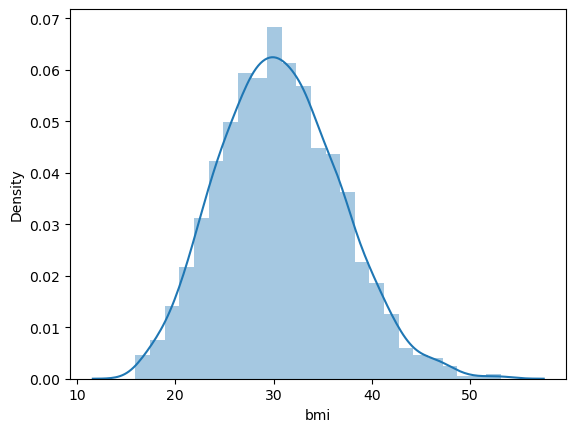

In [9]:
#e. Distrinution of bmi, age, charges colums
sns.distplot(data['bmi'])

C:\Users\moham\AppData\Local\Temp\ipykernel_15696\3262849815.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['age'])


<Axes: xlabel='age', ylabel='Density'>

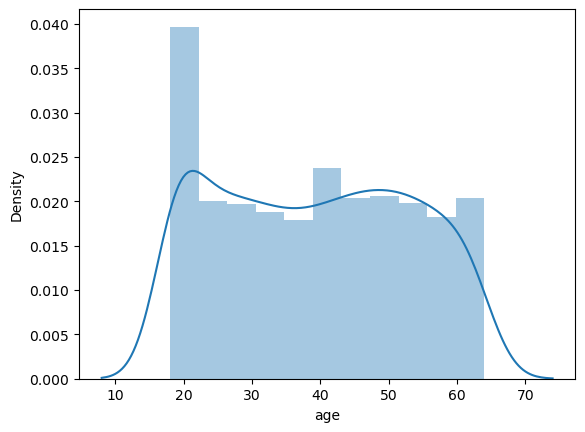

In [10]:
sns.distplot(data['age'])

C:\Users\moham\AppData\Local\Temp\ipykernel_15696\3303687566.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['charges'])


<Axes: xlabel='charges', ylabel='Density'>

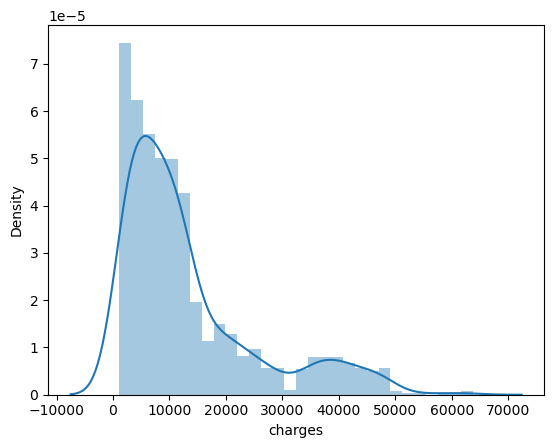

In [11]:
sns.distplot(data['charges'])

<Axes: xlabel='bmi'>

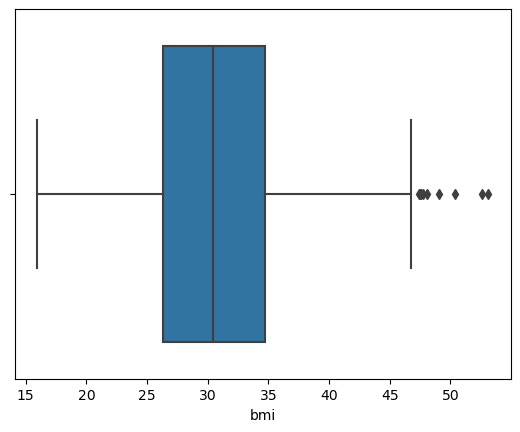

In [12]:
#f. Check for presence of outliers in bmi, age, charges column
sns.boxplot(x = data['bmi'])

<Axes: xlabel='age'>

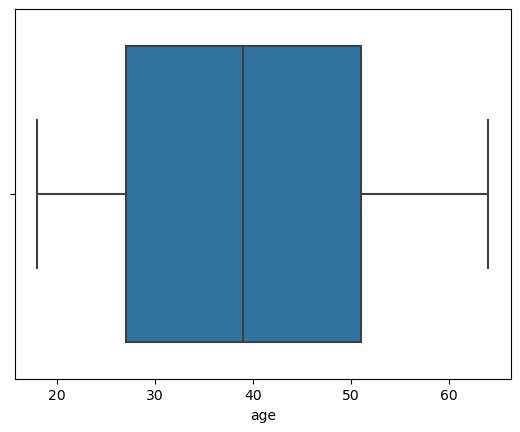

In [13]:
sns.boxplot(x = data['age'])

<Axes: xlabel='charges'>

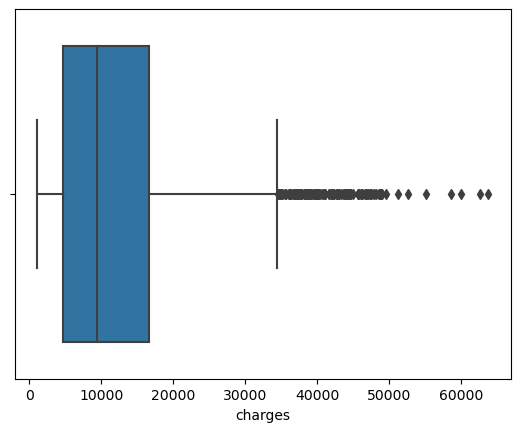

In [14]:
sns.boxplot(x = data['charges'])

In [15]:
#g. Measure of skweness of bmi, age, charges column
print('Skewness of bmi : ',stats.skew(data['bmi']))
print('Skewness of age : ',stats.skew(data['age']))
print('Skewness of charges : ',stats.skew(data['charges']))

Skewness of bmi :  0.28372857291709386
Skewness of age :  0.055610083072599126
Skewness of charges :  1.5141797118745743


<Axes: xlabel='children', ylabel='charges'>

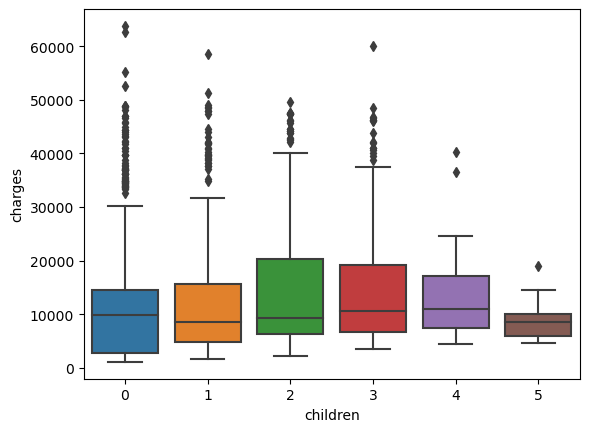

In [16]:
#h.  Distribution of categorical columns
sns.boxplot(x = 'children', y ='charges',data = data)

<Axes: xlabel='sex', ylabel='charges'>

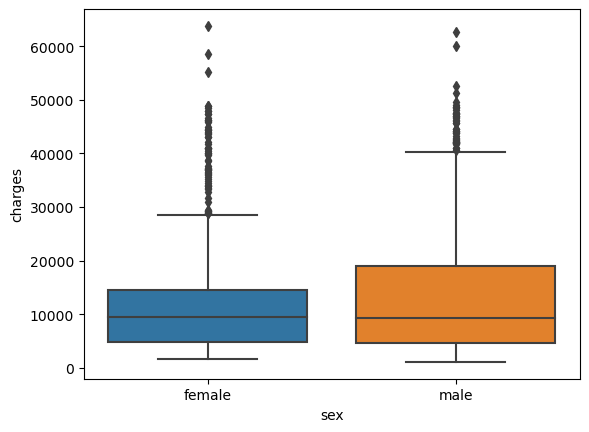

In [17]:
sns.boxplot(x = 'sex', y ='charges',data = data)

<Axes: xlabel='region', ylabel='charges'>

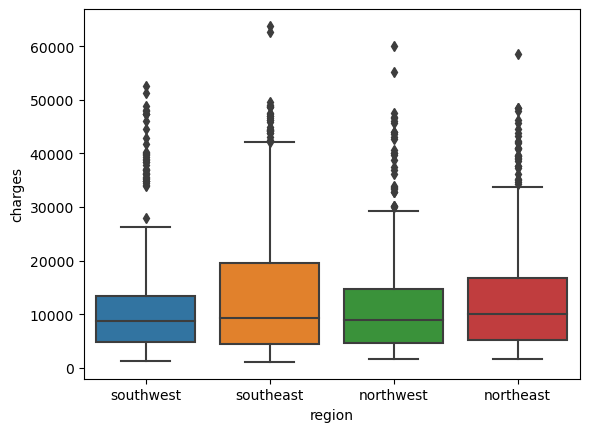

In [18]:
sns.boxplot(x = 'region', y ='charges',data = data)

<Axes: xlabel='smoker', ylabel='charges'>

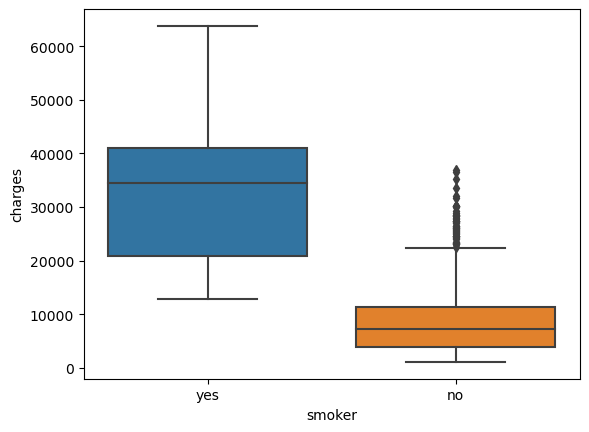

In [19]:
sns.boxplot(x = 'smoker', y ='charges',data = data)

<Axes: xlabel='children', ylabel='region'>

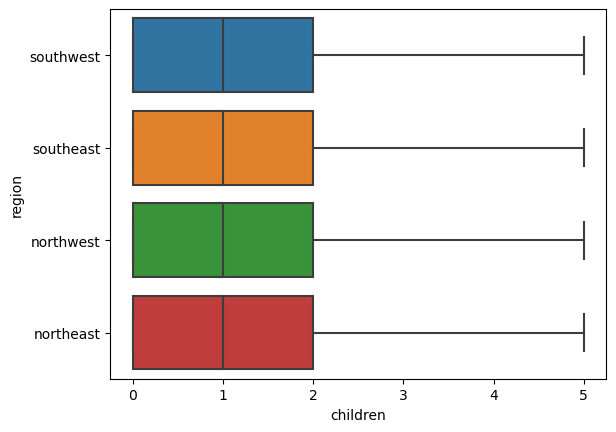

In [20]:
sns.boxplot(x = 'children', y ='region',data = data)

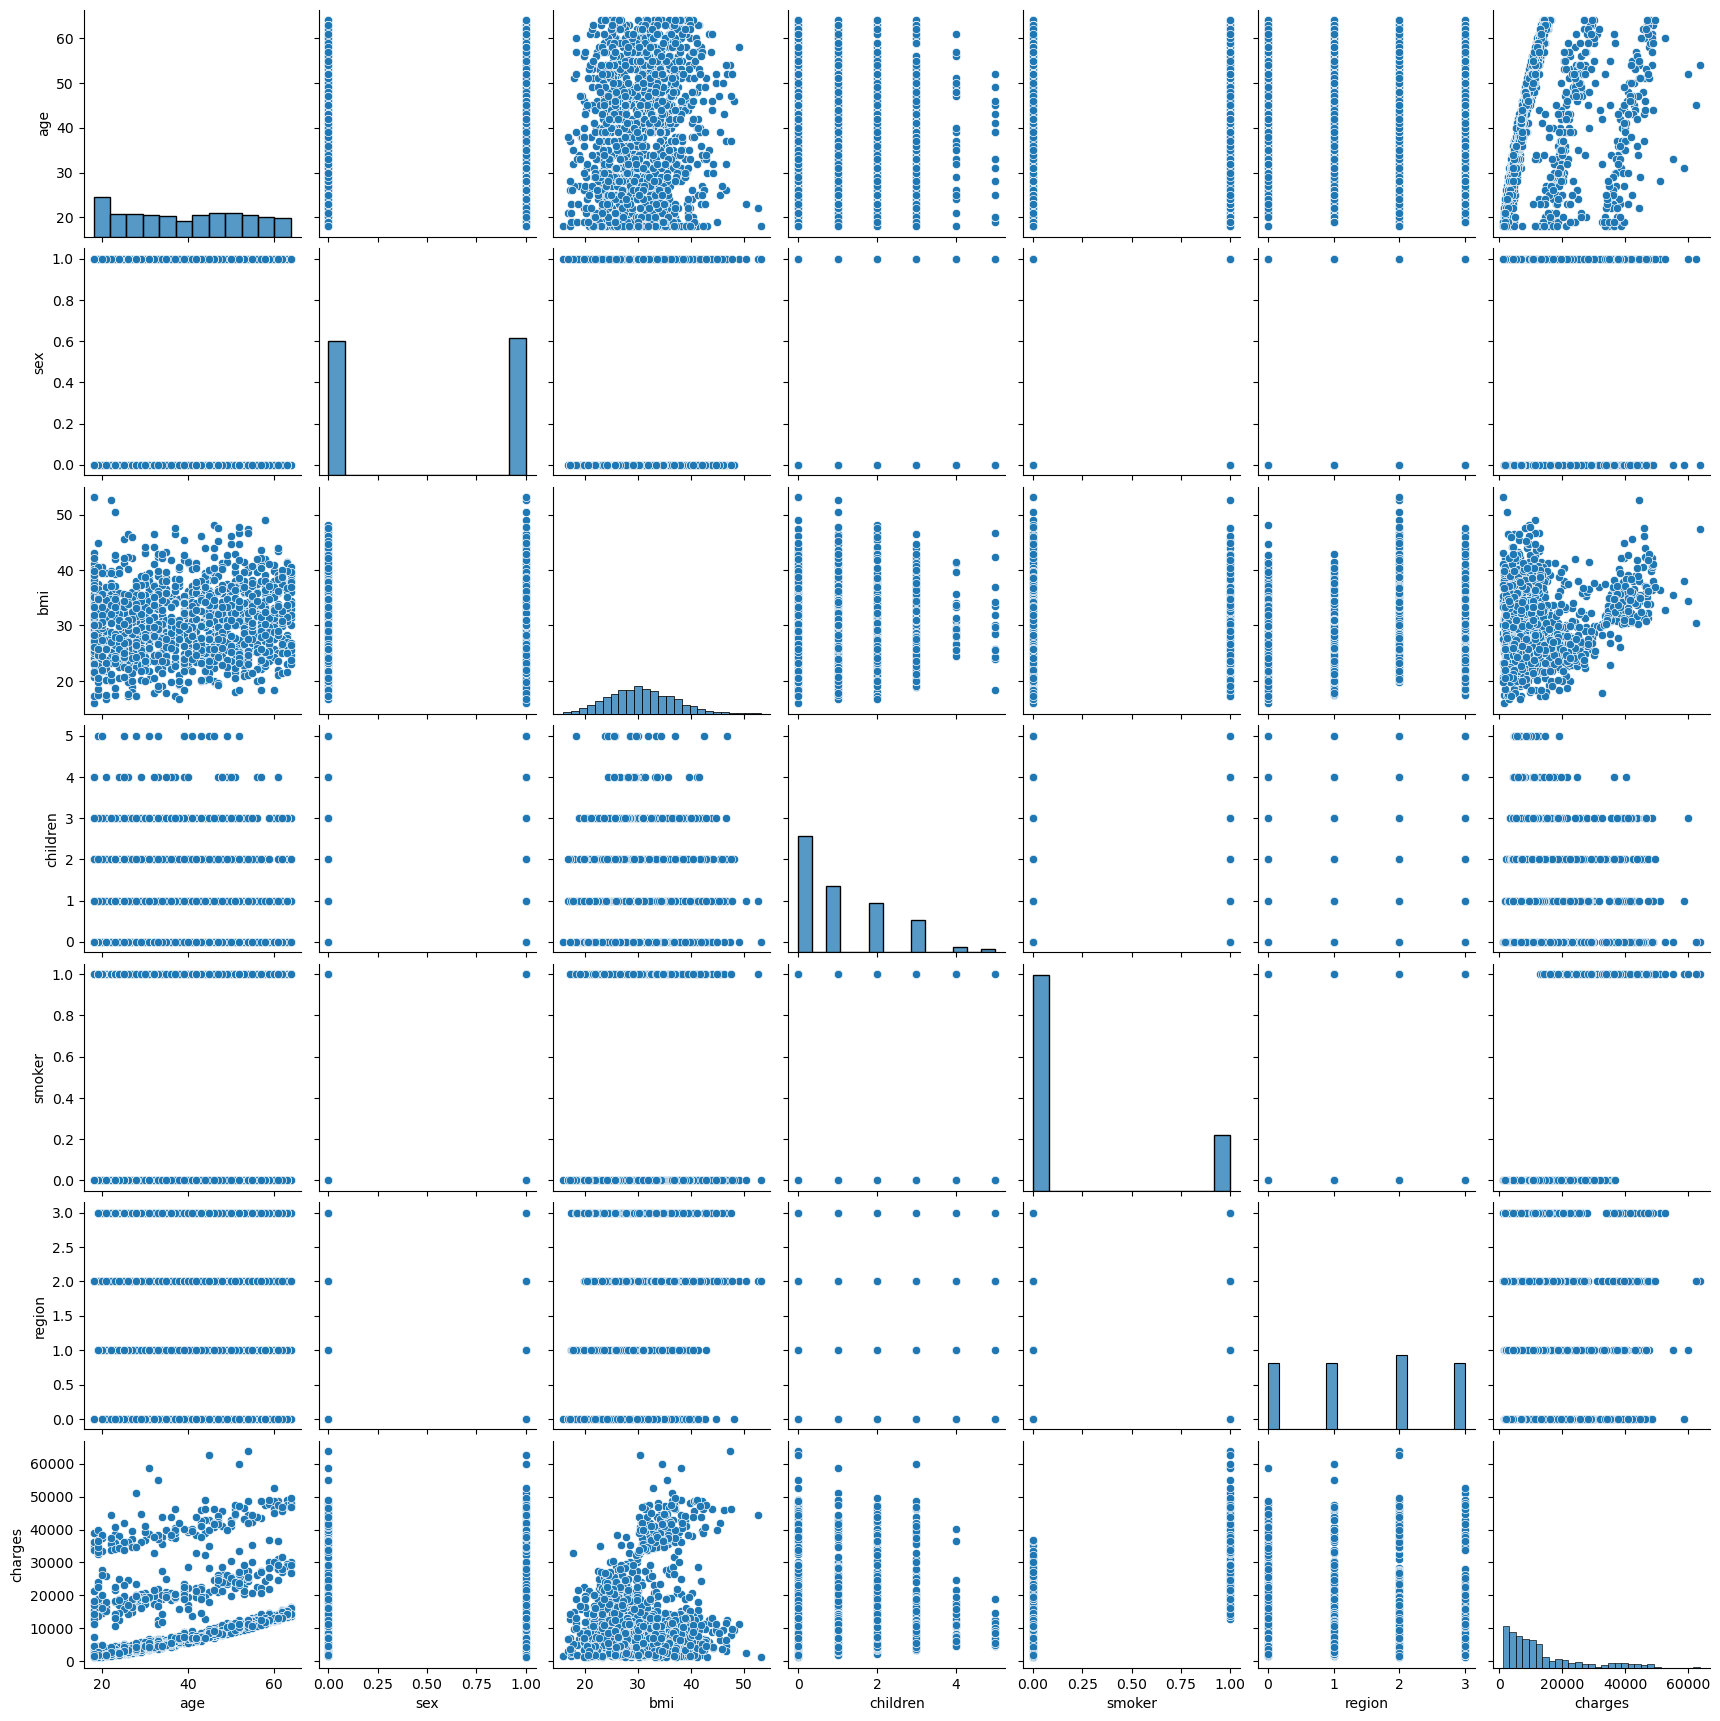

In [24]:
#i. Pairplot that incluces all the columns of data
data_encoded = data.copy()
# Fixed: assigning multiple label-encoded columns at once via .loc can raise a
# dtype error in newer pandas. Encoding one column at a time avoids it.
for col in ['sex', 'smoker', 'region']:
    data_encoded[col] = LabelEncoder().fit_transform(data[col])
sns.pairplot(data_encoded)

In [25]:
#Answer the follow Question with statistical evidence 
#a. Do charges of people who smoke differ significantly 
#from the people who don't?
ha="charges of smokers and non smokers are not the same"
H0="charges of smokers & non smokers are same"


In [26]:
x = np.array(data[data.smoker=='yes'].charges)
y = np.array(data[data.smoker=='no'].charges)

In [28]:
from scipy.stats import ttest_ind
test,p_value=ttest_ind(x,y)

In [30]:
alpha=0.05
if p_value>=alpha:
    print("Accept Ha")
else:
    print("Reject H0")

Reject H0


In [31]:
#b. Does bmi of males differ signifcantly from that of females?
ha="Gender has an impact on bmi"
H0="Gender has no impact on bmi"

In [38]:
x=np.array(data[data.sex==0].bmi)
y=np.array(data[data.sex==1].bmi)

In [39]:
t,p_value=ttest_ind(x,y)
if(p_value>=alpha):
    print("Accept Ha")
else:
    print("Reject H0")

Accept Ha


In [40]:
#c. Is the proportion of smokers significantly different in different gender?
Ha="Gender has an effect on smoking habits"
H0="Gender has no effect on smoking habits"

In [42]:
cross_tab_data=pd.crosstab(data['sex'],data['smoker'])

In [45]:
test,p_value,a,b=stats.chi2_contingency(cross_tab_data)

In [46]:
if(p_value>=alpha):
    print("Accept H0")
else:
    print("Reject H0")

Reject H0


In [48]:
#d. the proportion of of bmi across women with no children,one child and two children,the same? 
Ha="No. of children has an effect on bmi"
H0="No. of children has no effect on bmi"

In [49]:
female_data=data[data['sex']==0]
zero=female_data[female_data.children==0]['bmi']
one=female_data[female_data.children==1]['bmi']
two=female_data[female_data.children==2]['bmi']

In [51]:
test,p_value=stats.f_oneway(zero,one,two)

In [52]:
if(p_value>=alpha):
    print("Accept Ha")
else:
    print("Reject H0")

Accept Ha
